<a href="https://colab.research.google.com/github/Adithiya2007/Credit-Card-Fraud-detection/blob/main/creditcardfraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Credit Card Fraud Detection
Step 1 — Load and inspect the data
"""

import pandas as pd

# ── Load the CSV ─────────────────────────────────────────────────────────────
# Change the path below if your file is in a different folder
df = pd.read_csv("/creditcard.csv")

# ── How big is it? ────────────────────────────────────────────────────────────
print("Shape (rows, columns):", df.shape)

# ── What are the columns? ─────────────────────────────────────────────────────
print("\nColumn names:")
print(df.columns.tolist())

# ── Any missing values? ───────────────────────────────────────────────────────
print("\nMissing values per column:")
print(df.isnull().sum())

# ── What does one row look like? ──────────────────────────────────────────────
print("\nFirst transaction (row 0):")
print(df.iloc[0])
print(df['Class'].value_counts())
print()
print(df['Class'].value_counts(normalize=True) * 100)

Shape (rows, columns): (263383, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64

First transaction (row 0):
Time        0.000000
V1         -1.359807
V2         -0.072781
V3          2.536347
V4          1.378155
V5         -0.338321
V6          0.462388
V7          0.239599
V8          0.098698
V9          0.363787
V10         0.090794
V11        -0.551600
V12        -0.617801
V13        -0.991390

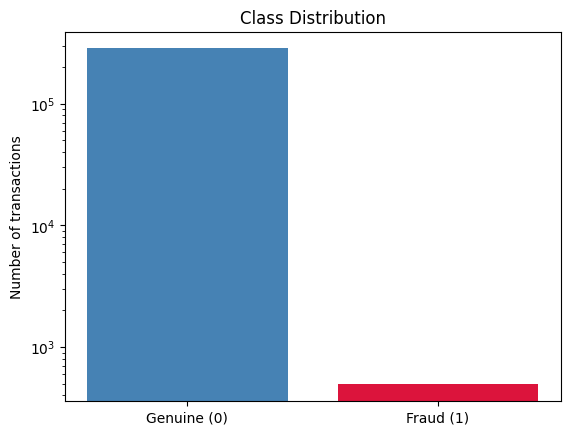

In [2]:
import matplotlib.pyplot as plt

labels = ['Genuine (0)', 'Fraud (1)']
counts = [284315, 492]

plt.bar(labels, counts, color=['steelblue', 'crimson'])
plt.title('Class Distribution')
plt.ylabel('Number of transactions')
plt.yscale('log')  # log scale so fraud bar is actually visible
plt.show()

In [3]:
genuine = df[df['Class'] == 0]['Amount']
fraud   = df[df['Class'] == 1]['Amount']

print("Genuine transactions:")
print(genuine.describe().round(2))

print("\nFraud transactions:")
print(fraud.describe().round(2))

Genuine transactions:
count    262903.00
mean         89.85
std         249.11
min           0.00
25%           5.99
50%          22.80
75%          79.00
max       19656.53
Name: Amount, dtype: float64

Fraud transactions:
count     479.00
mean      121.66
std       258.17
min         0.00
25%         1.00
50%         8.64
75%       105.35
max      2125.87
Name: Amount, dtype: float64


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])

print(df[['Amount', 'Amount_Scaled']].head(10))

   Amount  Amount_Scaled
0  149.62       0.239703
1    2.69      -0.350072
2  378.66       1.159067
3  123.50       0.134858
4   69.99      -0.079931
5    3.67      -0.346138
6    4.99      -0.340840
7   40.80      -0.197099
8   93.20       0.013234
9    3.68      -0.346098


In [5]:
df = df.drop(columns=['Time', 'Amount'])

print("Remaining columns:", df.shape[1])
print(df.head(3))

Remaining columns: 30
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   

         V8        V9       V10  ...       V21       V22       V23       V24  \
0  0.098698  0.363787  0.090794  ... -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425 -0.166974  ... -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  0.207643  ...  0.247998  0.771679  0.909412 -0.689281   

        V25       V26       V27       V28  Class  Amount_Scaled  
0  0.128539 -0.189115  0.133558 -0.021053    0.0       0.239703  
1  0.167170  0.125895 -0.008983  0.014724    0.0      -0.350072  
2 -0.327642 -0.139097 -0.055353 -0.059752    0.0       1.159067  

[3 rows x 30 columns]


In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Reload the data fresh
df = pd.read_csv('/creditcard.csv')

# Scale Amount
scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])

# Drop Time and original Amount
df = df.drop(columns=['Time', 'Amount'])

# Split features and target
X = df.drop(columns=['Class'])
y = df['Class']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)
print()
print("Fraud cases in training set:", int(y_train.sum()))
print("Fraud cases in test set:    ", int(y_test.sum()))

Training set size: (227845, 29)
Test set size:     (56962, 29)

Fraud cases in training set: 394
Fraud cases in test set:     98


In [ ]:
# Dataset: download creditcard.csv from
# https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [14]:
!pip install imbalanced-learn -q

In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  Genuine: {(y_train == 0).sum()}")
print(f"  Fraud:   {(y_train == 1).sum()}")

print("\nAfter SMOTE:")
print(f"  Genuine: {(y_train_sm == 0).sum()}")
print(f"  Fraud:   {(y_train_sm == 1).sum()}")

Before SMOTE:
  Genuine: 227451
  Fraud:   394

After SMOTE:
  Genuine: 227451
  Fraud:   227451
